<img src="https://udemedellin.edu.co/wp-content/uploads/2022/10/logo_udemedellin2.png" width="30%">

<b>ESPECIALIZACIÓN EN CIENCIA DE DATOS E INGELIGENCIA ARTIFICIAL</b>

<strong>Fundamentos de Estadística para Ciencia de Datos</strong>

# Sesión 3 — Distribuciones teóricas y normalidad

## Objetivos de aprendizaje

Al finalizar esta sesión serás capaz de:

- Explicar qué es una variable aleatoria y cómo se asignan probabilidades en distribuciones discretas y continuas.
- Reconocer las distribuciones discretas y continuas más comunes en ciencia de datos, y en qué situación aplica cada una.
- Explicar el Teorema del Límite Central y por qué es la base de buena parte de la inferencia estadística.
- Evaluar si una variable empírica se aproxima a una distribución normal, usando medidas numéricas, pruebas estadísticas y herramientas gráficas.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="deep")
%matplotlib inline

pd.set_option("display.precision", 3)
rng = np.random.default_rng(42)

## 1. ¿Por qué importan las distribuciones de probabilidad en ciencia de datos?

En la sesión anterior describimos datos que **ya observamos**. Las distribuciones de probabilidad son **modelos matemáticos** que indican cómo se comportaría una variable si pudiéramos observarla infinitas veces, y son la base de:

- **Simulación**: generar datos sintéticos realistas (e.g. simular tiempos de espera, demanda, fallas).
- **Modelos generativos y probabilísticos**: Naive Bayes asume una distribución por clase; muchos modelos de series de tiempo asumen ruido normal; modelos de conteo (e.g. demanda de productos) suelen usar Poisson o binomial negativa.
- **Pruebas de hipótesis e intervalos de confianza**: casi toda la inferencia estadística asume (explícita o implícitamente, vía el Teorema del Límite Central) que algo se distribuye de cierta forma.
- **Detección de anomalías**: marcar un evento como "raro" requiere primero un modelo de qué es "normal" en términos probabilísticos.

Empecemos por el concepto que conecta los datos observados de la sesión anterior con estos modelos teóricos: la variable aleatoria.

## 2. Variable aleatoria y distribución de probabilidad

Una **variable aleatoria** $X$ es una función que asigna un número a cada resultado posible de un experimento aleatorio (e.g. número de clics en un anuncio, tiempo hasta la próxima falla de un servidor). Se clasifican igual que en la sesión 1:

- **Discreta**: toma un número contable de valores (e.g. número de errores por día).
- **Continua**: puede tomar cualquier valor dentro de un rango (e.g. tiempo de respuesta de una API).

### ¿Cómo se asignan las probabilidades?

| | Discreta | Continua |
|---|---|---|
| Función | Función de masa de probabilidad (**PMF**): $P(X = x)$ | Función de densidad de probabilidad (**PDF**): $f(x)$ |
| Probabilidad de un punto exacto | Puede ser mayor que 0 | Siempre es 0: $P(X = x) = 0$ |
| Cómo se calcula una probabilidad | Se suman valores de la PMF | Se calcula el **área bajo la curva** de la PDF entre dos puntos |
| Función acumulada (CDF) | $F(x) = P(X \le x) = \sum_{x_k \leq x} P(X = x_k)$ | $F(x) = P(X \le x) = \int_{-\infty}^{x} f(t)\, dt$ |
| Probabilidad total | $\displaystyle\sum_{x} P(X = x) = 1$ | $\displaystyle\int_{-\infty}^{\infty} f(x)\, dx = 1$ |

Que la probabilidad total sume 1 es parte de la **definición** de PMF y PDF, cualquier función que no sume 1 sobre todos los valores posibles no es una distribución de probabilidad válida.

Cada distribución tiene, además, un **valor esperado** $E[X]$ (el "centro" teórico, análogo a la media) y una **varianza** $Var(X)$ (la dispersión teórica, análoga a la varianza).

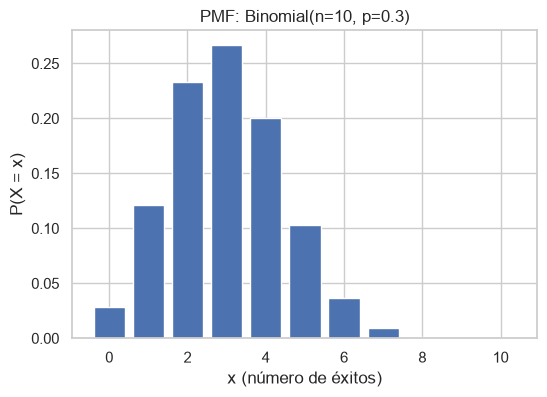

Suma de todas las probabilidades: 1.000


In [4]:
# Discreta: PMF de una binomial (n=10 ensayos, p=0.3 de éxito)
x_binom = np.arange(0, 11)
pmf_binom = stats.binom.pmf(x_binom, n=10, p=0.3)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x_binom, pmf_binom, color="#4C72B0")
ax.set_title("PMF: Binomial(n=10, p=0.3)")
ax.set_xlabel("x (número de éxitos)")
ax.set_ylabel("P(X = x)")
plt.show()

print(f"Suma de todas las probabilidades: {pmf_binom.sum():.3f}")

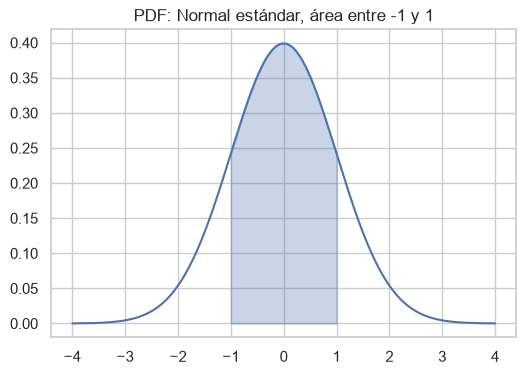

P(-1 <= X <= 1) = área sombreada = 0.683
P(-inf < X < inf) = todos los valores posibles = 0.999968


In [15]:
# Continua: PDF de una normal estándar, con el área entre -1 y 1 sombreada
x_norm = np.linspace(-4, 4, 500)
pdf_norm = stats.norm.pdf(x_norm, loc=0, scale=1)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_norm, pdf_norm, color="#4C72B0")
x_fill = np.linspace(-1, 1, 200)
ax.fill_between(x_fill, stats.norm.pdf(x_fill), color="#4C72B0", alpha=0.3)
ax.set_title("PDF: Normal estándar, área entre -1 y 1")
plt.show()

probability = stats.norm.cdf(1) - stats.norm.cdf(-1)

# Probabilidad todo el intervalo
x_inf = 4
probability_inf = stats.norm.cdf(x_inf)

print(f"P(-1 <= X <= 1) = área sombreada = {probability:.3f}")
print(f"P(-inf < X < inf) = todos los valores posibles = {probability_inf:.6f}")

**Ejercicio:** usando `stats.norm.cdf`, calcula $P(X > 2)$ para una normal estándar. Pista: recuerda que el área total bajo la curva es 1.

In [4]:
# Ejercicio: probabilidades en una distribución continua
# TODO: calcula P(X > 2) para una normal estándar usando stats.norm.cdf

## 3. Distribuciones discretas

### Binomial

Cuenta el número de éxitos en $n$ ensayos independientes, cada uno con la misma probabilidad de éxito $p$.

$$E[X] = np \qquad Var(X) = np(1-p)$$

**Casos de uso:** número de clics en $n$ impresiones de un anuncio (con tasa de clic fija), número de piezas defectuosas en un lote **con reemplazo**, número de veces que un modelo acierta en $n$ predicciones independientes.

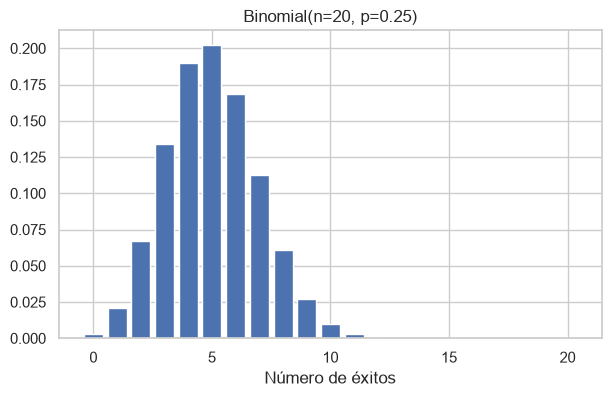

P(X = 5) = 0.202
P(X <= 5) = 0.617
Media teórica E[X] = n*p = 5.00
Varianza teórica Var(X) = n*p*(1-p) = 3.75


In [16]:
n_trials, p_success = 20, 0.25
binomial_distribution = stats.binom(n=n_trials, p=p_success)

x = np.arange(0, n_trials + 1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x, binomial_distribution.pmf(x), color="#4C72B0")
ax.set_title(f"Binomial(n={n_trials}, p={p_success})")
ax.set_xlabel("Número de éxitos")
plt.show()

print(f"P(X = 5) = {binomial_distribution.pmf(5):.3f}")
print(f"P(X <= 5) = {binomial_distribution.cdf(5):.3f}")
print(f"Media teórica E[X] = n*p = {binomial_distribution.mean():.2f}")
print(f"Varianza teórica Var(X) = n*p*(1-p) = {binomial_distribution.var():.2f}")

### Poisson

Cuenta el número de eventos que ocurren en un intervalo fijo de tiempo o espacio, dado una tasa promedio $\lambda$ de ocurrencia. Es el límite natural de una binomial cuando $n$ es muy grande y $p$ muy pequeño.

Su media teórica es directamente el parámetro: $E[X] = \lambda$. Una propiedad particular de la Poisson es que también $Var(X) = \lambda$: media y varianza son iguales ("equidispersión"), lo que la hace un mal modelo cuando los datos reales muestran más dispersión de la que su propia media predice (ver **binomial negativa** más abajo).

**Casos de uso:** número de solicitudes que llegan a un servidor por minuto, número de fallas de una máquina por mes, número de errores de un sistema por día.

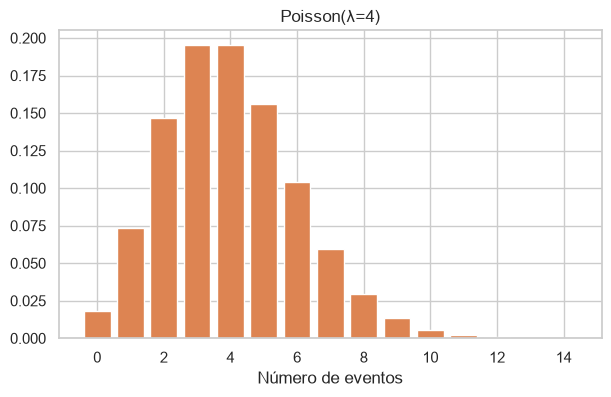

P(X = 4) = 0.195
P(X >= 8) = 0.051
Media teórica E[X] = lambda = 4.00
Varianza teórica Var(X) = lambda = 4.00


In [17]:
lam = 4
poisson_distribution = stats.poisson(mu=lam)

x = np.arange(0, 15)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x, poisson_distribution.pmf(x), color="#DD8452")
ax.set_title(f"Poisson(λ={lam})")
ax.set_xlabel("Número de eventos")
plt.show()

print(f"P(X = 4) = {poisson_distribution.pmf(4):.3f}")
print(f"P(X >= 8) = {1 - poisson_distribution.cdf(7):.3f}")
print(f"Media teórica E[X] = lambda = {poisson_distribution.mean():.2f}")
print(f"Varianza teórica Var(X) = lambda = {poisson_distribution.var():.2f}")

### Hipergeométrica

Igual que la binomial (contar éxitos en varios ensayos), pero el muestreo es **sin reemplazo** de una población finita, así que la probabilidad de éxito cambia en cada ensayo.

Con una población de tamaño $N$ que contiene $K$ éxitos, y una muestra de tamaño $n$:

$$E[X] = n\frac{K}{N} \qquad Var(X) = n\frac{K}{N}\left(1-\frac{K}{N}\right)\frac{N-n}{N-1}$$

El factor $\frac{N-n}{N-1}$ (corrección por población finita) es lo que distingue esta varianza de la binomial: la reduce, porque al no haber reemplazo hay menos incertidumbre que si cada ensayo fuera independiente.

**Casos de uso:** control de calidad al extraer una muestra de un lote finito sin reponer piezas, probabilidad de formar un comité con cierta composición, probabilidad de recibir cierta cantidad de cartas de un tipo en una mano.

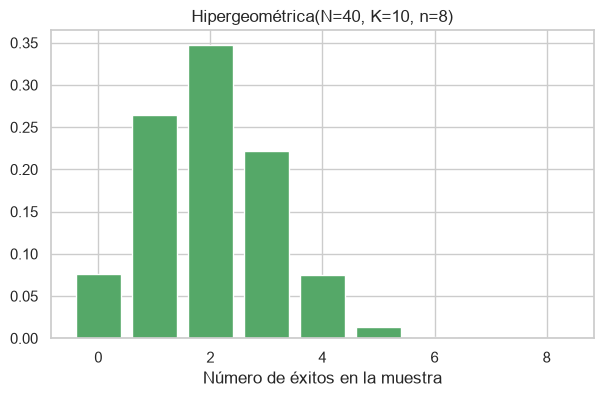

P(X = 2) = 0.347
Media teórica E[X] = 2.00
Varianza teórica Var(X) = 1.23


In [20]:
# Ejemplo: lote de 40 piezas (population_size), 10 de ellas defectuosas (population_successes).
# Se extrae una muestra de 8 piezas (sample_size) SIN reemplazo.
# X = número de piezas defectuosas encontradas en esa muestra de 8.
population_size, population_successes, sample_size = 40, 10, 8
hypergeometric_distribution = stats.hypergeom(M=population_size, n=population_successes, N=sample_size)

x = np.arange(0, min(population_successes, sample_size) + 1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x, hypergeometric_distribution.pmf(x), color="#55A868")
ax.set_title(f"Hipergeométrica(N={population_size}, K={population_successes}, n={sample_size})")
ax.set_xlabel("Número de éxitos en la muestra")
plt.show()

print(f"P(X = 2) = {hypergeometric_distribution.pmf(2):.3f}")
print(f"Media teórica E[X] = {hypergeometric_distribution.mean():.2f}")
print(f"Varianza teórica Var(X) = {hypergeometric_distribution.var():.2f}")

### Otras distribuciones discretas de referencia

| Distribución | Idea | $E[X]$ | $Var(X)$ | Caso de uso típico |
|---|---|---|---|---|
| Bernoulli($p$) | Un solo ensayo con éxito/fracaso (binomial con n=1) | $p$ | $p(1-p)$ | Si un usuario compra o no en una sola visita |
| Geométrica($p$) | Número de ensayos hasta el primer éxito | $1/p$ | $(1-p)/p^2$ | Número de llamadas de venta hasta lograr la primera venta |
| Binomial negativa($r$, $p$) | Número de ensayos hasta obtener $r$ éxitos | $r/p$ | $r(1-p)/p^2$ | Conteos "sobre-dispersos" en analítica web, alternativa a Poisson cuando la varianza supera a la media |
| Uniforme discreta($a$, $b$) | Todos los valores enteros de un rango igual de probables | $(a+b)/2$ | $(n^2-1)/12$, con $n=b-a+1$ | Lanzar un dado justo |

**Ejercicio:** usando `stats.poisson`, calcula la probabilidad de que un sistema reciba **exactamente 0 errores** en un día, si en promedio recibe 2.5 errores por día. ¿Te parece un valor alto o bajo?

In [19]:
# Ejercicio: distribuciones discretas
# TODO: calcula P(X = 0) para una Poisson con lambda = 2.5

## 4. Distribuciones continuas

### Uniforme

Todos los valores dentro de un intervalo $[a, b]$ son igual de probables.

$$E[X] = \frac{a+b}{2} \qquad Var(X) = \frac{(b-a)^2}{12}$$

**Casos de uso:** generación de números pseudoaleatorios, simulación de un tiempo de llegada cuando no se tiene ninguna otra información sobre el proceso.

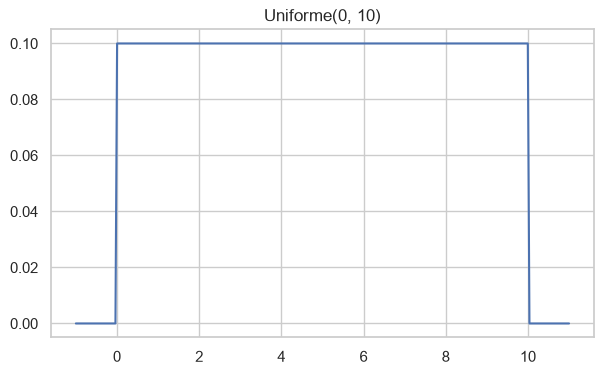

Media teórica: 5.00
Varianza teórica: 8.33
P(3 <= X <= 7) = 0.400


In [22]:
a, b = 0, 10
uniform_distribution = stats.uniform(loc=a, scale=b - a)

x = np.linspace(a - 1, b + 1, 300)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, uniform_distribution.pdf(x), color="#4C72B0")
ax.set_title(f"Uniforme({a}, {b})")
plt.show()

print(f"Media teórica: {uniform_distribution.mean():.2f}")
print(f"Varianza teórica: {uniform_distribution.var():.2f}")
print(f"P(3 <= X <= 7) = {uniform_distribution.cdf(7) - uniform_distribution.cdf(3):.3f}")

### Normal

La distribución en forma de campana, simétrica alrededor de su media $\mu$, con dispersión controlada por $\sigma$. Es central en estadística en gran parte gracias al Teorema del Límite Central (sección 5).

A diferencia de las demás distribuciones de esta sección, aquí no hay que derivar una fórmula aparte: sus dos parámetros son directamente $E[X] = \mu$ y $Var(X) = \sigma^2$.

**Casos de uso:** errores de medición, alturas o pesos en una población, y como aproximación de la distribución de un promedio muestral (sin importar la distribución original de los datos).

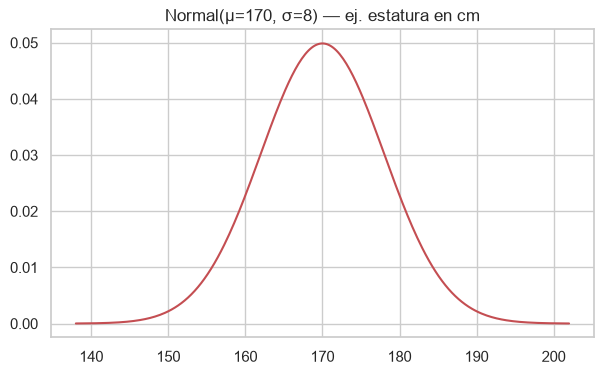

Media teórica E[X] = mu = 170.00
Varianza teórica Var(X) = sigma^2 = 64.00
P(162 <= X <= 178) [±1 sigma] = 0.683


In [23]:
mu, sigma = 170, 8
normal_distribution = stats.norm(loc=mu, scale=sigma)

x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 300)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, normal_distribution.pdf(x), color="#C44E52")
ax.set_title(f"Normal(μ={mu}, σ={sigma}) — ej. estatura en cm")
plt.show()

print(f"Media teórica E[X] = mu = {normal_distribution.mean():.2f}")
print(f"Varianza teórica Var(X) = sigma^2 = {normal_distribution.var():.2f}")
print(f"P(162 <= X <= 178) [±1 sigma] = {normal_distribution.cdf(178) - normal_distribution.cdf(162):.3f}")

### Exponencial

Modela el **tiempo entre eventos** de un proceso Poisson (el mismo proceso que en la sección 3), con tasa $\lambda$.

$$E[X] = \frac{1}{\lambda} \qquad Var(X) = \frac{1}{\lambda^2}$$

**Casos de uso:** tiempo entre llegadas de clientes a una fila, tiempo de vida de un componente electrónico que no se desgasta con el uso.

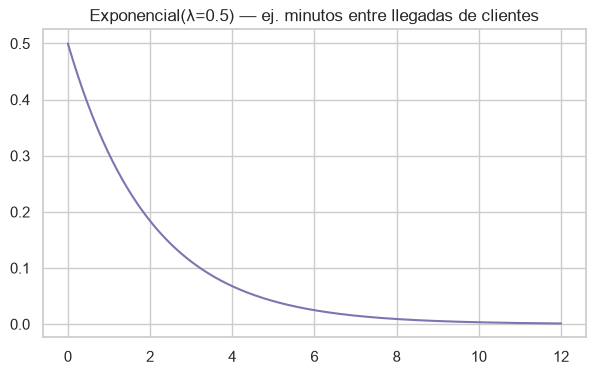

Media teórica (tiempo esperado entre eventos): 2.00
Varianza teórica: 4.00
P(esperar más de 5 minutos) = 0.082


In [24]:
rate = 0.5
exponential_distribution = stats.expon(scale=1 / rate)

x = np.linspace(0, 12, 300)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, exponential_distribution.pdf(x), color="#8172B2")
ax.set_title(f"Exponencial(λ={rate}) — ej. minutos entre llegadas de clientes")
plt.show()

print(f"Media teórica (tiempo esperado entre eventos): {exponential_distribution.mean():.2f}")
print(f"Varianza teórica: {exponential_distribution.var():.2f}")
print(f"P(esperar más de 5 minutos) = {1 - exponential_distribution.cdf(5):.3f}")

### Otras distribuciones continuas de referencia

| Distribución | Idea | $E[X]$ | $Var(X)$ | Caso de uso típico |
|---|---|---|---|---|
| Gamma($k$, $\theta$) | Suma de $k$ tiempos exponenciales | $k\theta$ | $k\theta^2$ | Tiempo total hasta que ocurren $k$ eventos, tiempos de espera acumulados |
| Beta($\alpha$, $\beta$) | Modela proporciones/probabilidades entre 0 y 1 | $\dfrac{\alpha}{\alpha+\beta}$ | $\dfrac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}$ | Modelar una tasa de conversión desconocida (muy usada en estadística bayesiana) |
| Chi-cuadrado($k$) | Suma de cuadrados de normales estándar | $k$ | $2k$ | Pruebas de bondad de ajuste, distribución de la varianza muestral |
| t-Student($\nu$) | Como la normal, pero con colas más pesadas | $0$ * | $\dfrac{\nu}{\nu-2}$ * | Pruebas t cuando se estima la desviación estándar poblacional con muestras pequeñas |
| Log-normal($\mu$, $\sigma$) | Su logaritmo se distribuye normal | $e^{\mu+\sigma^2/2}$ | $(e^{\sigma^2}-1)e^{2\mu+\sigma^2}$ | Variables positivas y asimétricas: ingresos, precios, tiempos de vida |
| Weibull($k$, $\lambda$) | Modela tiempos hasta un fallo | $\lambda\,\Gamma(1+1/k)$ | $\lambda^2\left[\Gamma(1+2/k)-\Gamma(1+1/k)^2\right]$ | Análisis de confiabilidad y supervivencia de componentes/equipos |

\* La media de la t-Student solo existe para $\nu > 1$, y su varianza solo para $\nu > 2$ (para $\nu = 1$ es la distribución de Cauchy, que no tiene media ni varianza finitas).

**Ejercicio:** usando `stats.expon`, calcula la probabilidad de que el tiempo entre llegadas sea de **menos de 1 minuto**, con la misma tasa `λ = 0.5` del ejemplo anterior.

In [12]:
# Ejercicio: distribuciones continuas
# TODO: calcula P(X < 1) para la distribución exponencial con tasa 0.5

## 5. Teorema del Límite Central (TLC)

> Si tomamos muestras de tamaño $n$ (suficientemente grande) de **cualquier** población con varianza finita, sin importar su forma, la distribución de las **medias muestrales** se aproxima a una distribución normal a medida que $n$ crece.

Esto es sorprendente: no importa si la población original es simétrica, sesgada, o discreta — el promedio de muchas muestras de ella tiende a comportarse como una normal. Veámoslo con una población deliberadamente muy asimétrica: una exponencial.

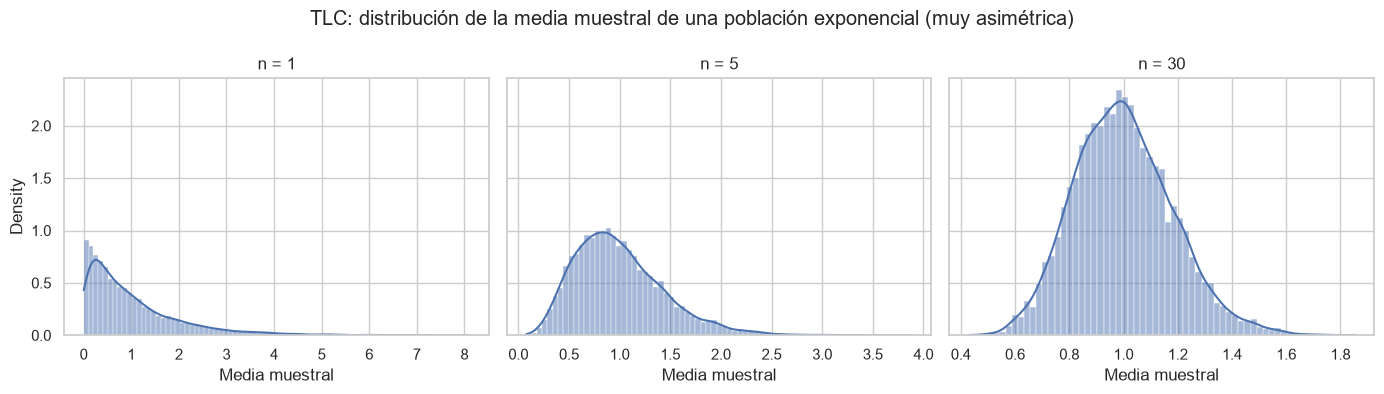

In [26]:
# Exponencial(1): ej. tiempo entre llegadas de clientes, población deliberadamente muy asimétrica
exponential_population = stats.expon(scale=1)
sample_sizes = [1, 5, 30]
num_simulations = 10_000

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, n in zip(axes, sample_sizes):
    sample_means = exponential_population.rvs(size=(num_simulations, n), random_state=rng).mean(axis=1)
    sns.histplot(sample_means, kde=True, stat="density", ax=ax)
    ax.set_title(f"n = {n}")
    ax.set_xlabel("Media muestral")

fig.suptitle("TLC: distribución de la media muestral de una población exponencial (muy asimétrica)")
plt.tight_layout()
plt.show()

Con `n = 1` la distribución de "medias muestrales" es simplemente la población original (muy sesgada); a medida que `n` crece, la distribución de la media se vuelve cada vez más simétrica y con forma de campana.

Ahora veamos que esto **no depende de qué población partamos**: tomemos tres poblaciones muy distintas (uniforme, exponencial y binomial) y comparemos la distribución de su media muestral con `n = 30`.

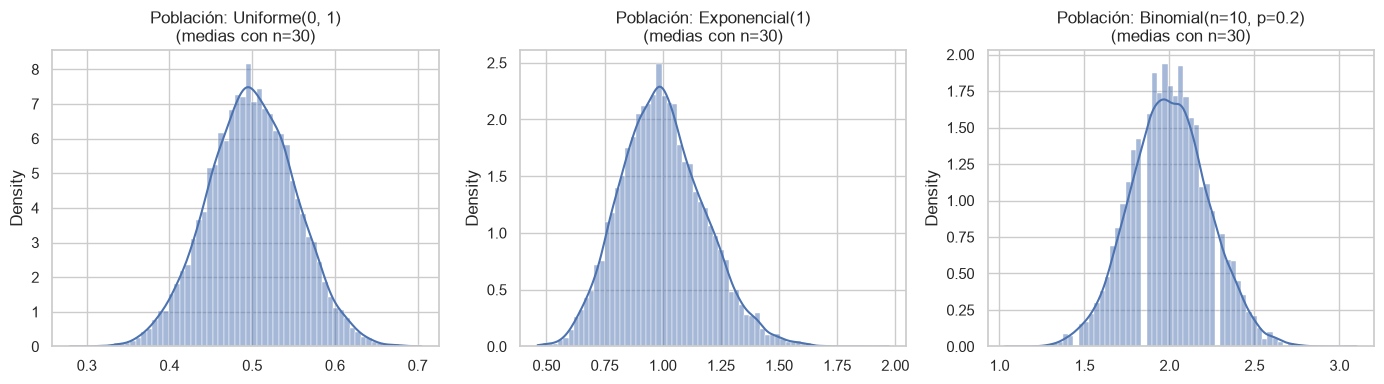

In [31]:
populations = {
    "Uniforme(0, 1)": stats.uniform(0, 1),
    "Exponencial(1)": stats.expon(scale=1),
    "Binomial(n=10, p=0.2)": stats.binom(10, 0.2),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, distribution) in zip(axes, populations.items()):
    sample_means = distribution.rvs(size=(num_simulations, 30), random_state=rng).mean(axis=1)
    sns.histplot(sample_means, kde=True, stat="density", ax=ax)
    ax.set_title(f"Población: {name}\n(medias con n=30)")

plt.tight_layout()
plt.show()

### El TLC también aplica sumando distribuciones distintas (no solo repitiendo la misma)

La versión que acabamos de ver toma $n$ observaciones de la **misma** población. Pero el TLC tiene una versión más general (Lyapunov/Lindeberg): si sumas variables **independientes pero de distribuciones distintas**, con varianza finita, y sin que una sola domine la varianza total, esa suma también tiende a una normal. Combinemos 6 distribuciones muy distintas entre sí (simétricas, sesgadas a la derecha, sesgadas a la izquierda, discretas) y veamos cómo la asimetría de la suma se reduce a medida que sumamos más términos.

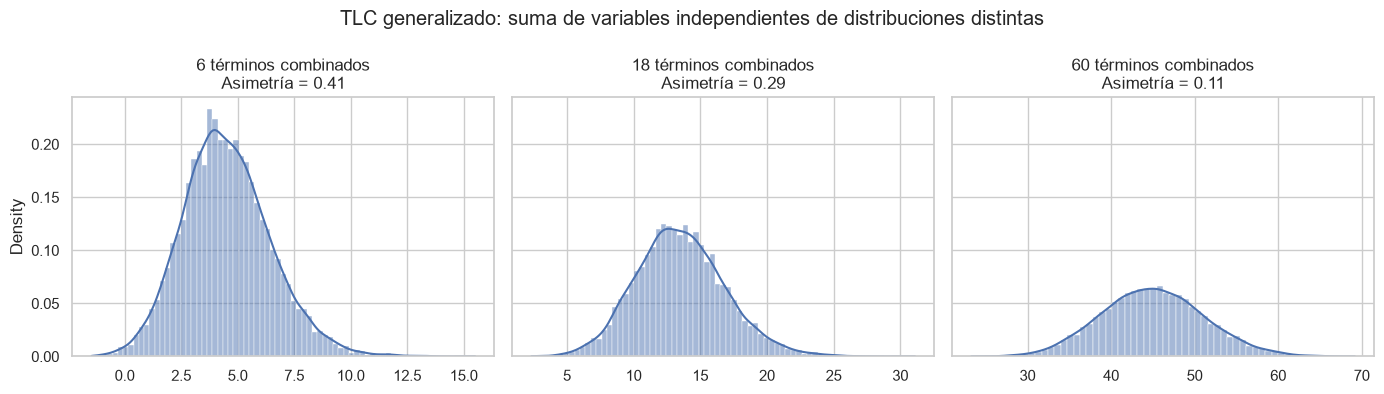

In [33]:
# 6 distribuciones muy distintas: simétricas, sesgadas a la derecha, sesgadas a la izquierda, discreta
mixed_distributions = [
    stats.uniform(0, 1),      # simétrica
    stats.expon(scale=1),     # sesgada a la derecha
    stats.binom(10, 0.2),     # discreta, sesgada a la derecha
    stats.beta(2, 5),         # sesgada a la derecha
    stats.beta(5, 2),         # sesgada a la izquierda
    stats.norm(0, 1),         # simétrica
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, n_terms in zip(axes, [6, 18, 60]):
    combined_sum = np.zeros(num_simulations)
    for i in range(n_terms):
        distribution = mixed_distributions[i % len(mixed_distributions)]
        combined_sum += distribution.rvs(size=num_simulations, random_state=rng)
    sns.histplot(combined_sum, kde=True, stat="density", ax=ax)
    ax.set_title(f"{n_terms} términos combinados\nAsimetría = {stats.skew(combined_sum):.2f}")

fig.suptitle("TLC generalizado: suma de variables independientes de distribuciones distintas")
plt.tight_layout()
plt.show()

### ¿Por qué es tan importante en estadística y ciencia de datos?

- Es la razón por la que los **intervalos de confianza** y muchas **pruebas de hipótesis** (como la prueba t que usamos en la sesión 1) son válidos incluso cuando los datos originales no son normales: lo que necesitan ser aproximadamente normal es la distribución de la **media muestral**, no de los datos crudos.
- Justifica por qué el error de muchos modelos, al ser resultado de la suma de muchos factores pequeños e independientes, tiende a comportarse como una normal.
- Es la base teórica detrás de técnicas como el *bootstrap* y del uso extendido de la desviación estándar para construir márgenes de error.

## 6. Medidas de normalidad de distribuciones de datos numéricos

La distribución normal queda completamente definida por dos parámetros, $\mu$ (media) y $\sigma$ (desviación estándar), y cumple la **regla empírica**: ~68% de los datos cae dentro de ±1σ, ~95% dentro de ±2σ, ~99.7% dentro de ±3σ (la vimos de forma preliminar en la sesión 2, junto a la desigualdad de Chebyshev, válida para *cualquier* distribución).

**¿Por qué importa evaluar si una variable es aproximadamente normal?** Muchos métodos estadísticos clásicos (pruebas t, regresión lineal, ciertos intervalos de confianza) asumen normalidad —de los datos o, gracias al TLC, de un estadístico calculado sobre ellos—; si esa suposición se viola de forma importante, esos métodos pueden dar resultados poco confiables y conviene usar alternativas (transformaciones, pruebas no paramétricas).

### Medidas numéricas: asimetría y curtosis

- **Asimetría (skewness):** mide qué tan simétrica es la distribución. Cercana a 0 → simétrica; positiva → cola hacia la derecha; negativa → cola hacia la izquierda.
- **Curtosis (exceso, respecto a la normal):** mide qué tan pesadas son las colas. Cercana a 0 → colas similares a la normal; positiva → colas más pesadas (más atípicos de lo esperado); negativa → colas más ligeras.

In [34]:
normal_sample = rng.normal(0, 1, 1000)
skewed_sample = rng.exponential(1, 1000)
heavy_tailed_sample = rng.laplace(0, 1, 1000)

comparison = pd.DataFrame({
    "Distribución": ["Normal", "Sesgada (exponencial)", "Colas pesadas (Laplace)"],
    "Asimetría": [stats.skew(normal_sample), stats.skew(skewed_sample), stats.skew(heavy_tailed_sample)],
    "Curtosis (exceso)": [stats.kurtosis(normal_sample), stats.kurtosis(skewed_sample), stats.kurtosis(heavy_tailed_sample)],
})
comparison

,Distribución,Asimetría,Curtosis (exceso)
0,Normal,-0.116,-0.089
1,Sesgada (exponencial),2.072,6.496
2,Colas pesadas (Laplace),0.153,2.511


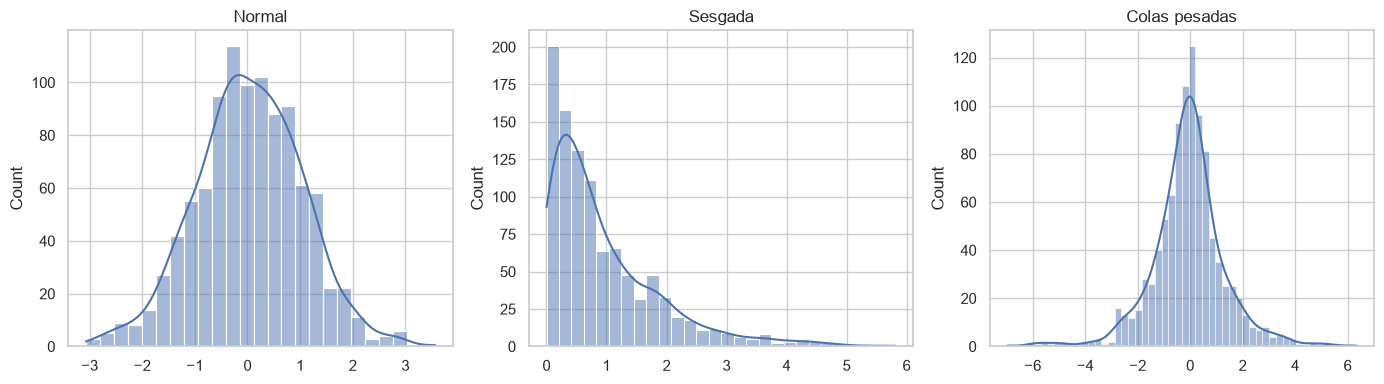

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, data, title in zip(axes, [normal_sample, skewed_sample, heavy_tailed_sample],
                              ["Normal", "Sesgada", "Colas pesadas"]):
    sns.histplot(data, kde=True, ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()

### Pruebas estadísticas de normalidad

Existen varias pruebas de hipótesis diseñadas específicamente para esto; todas comparten la misma estructura:

$$H_0: \text{los datos provienen de una distribución normal}$$

| Prueba | Idea general |
|---|---|
| Shapiro-Wilk | Compara los datos ordenados contra lo esperado bajo normalidad; buen desempeño con muestras pequeñas/medianas |
| Kolmogorov-Smirnov | Compara la distribución acumulada empírica contra la CDF normal teórica |
| Anderson-Darling | Similar a Kolmogorov-Smirnov, pero da más peso a las colas de la distribución |

Lo más importante para el día a día **no es el detalle de cada estadístico, sino cómo se interpreta el resultado**: igual que en la sesión 1, un p-valor bajo (< 0.05, el umbral más común) lleva a **rechazar H₀** (evidencia de que los datos no son normales); un p-valor alto lleva a **no rechazar H₀**, los datos son compatibles con normalidad, no es una prueba de que sí lo sean.

In [17]:
for name, data in [("Normal simulada", normal_sample), ("Sesgada simulada", skewed_sample)]:
    statistic, p_value = stats.shapiro(data)
    decision = "se rechaza H0 (no parece normal)" if p_value < 0.05 else "no se rechaza H0 (compatible con normalidad)"
    print(f"{name}: Shapiro-Wilk p-valor = {p_value:.4f} -> {decision}")

Normal simulada: Shapiro-Wilk p-valor = 0.5338 -> no se rechaza H0 (compatible con normalidad)
Sesgada simulada: Shapiro-Wilk p-valor = 0.0000 -> se rechaza H0 (no parece normal)


### Herramientas gráficas

- **Histograma + curva normal ajustada**: superponer la PDF de una normal con la media y desviación estándar de los datos.
- **QQ-plot (*quantile-quantile*)**: compara los cuantiles de los datos contra los cuantiles teóricos de una normal. Si los puntos caen sobre la línea diagonal, los datos son compatibles con normalidad; desviaciones sistemáticas (curvas, colas que se despegan) indican no-normalidad.
- **Boxplot y KDE** (sección 6-7 de la sesión 2): siguen siendo útiles para ver asimetría y atípicos de un vistazo.

Apliquemos todo esto a un caso real: `horsepower`, la variable de la sesión anterior donde ya habíamos notado que la media era mayor que la mediana.

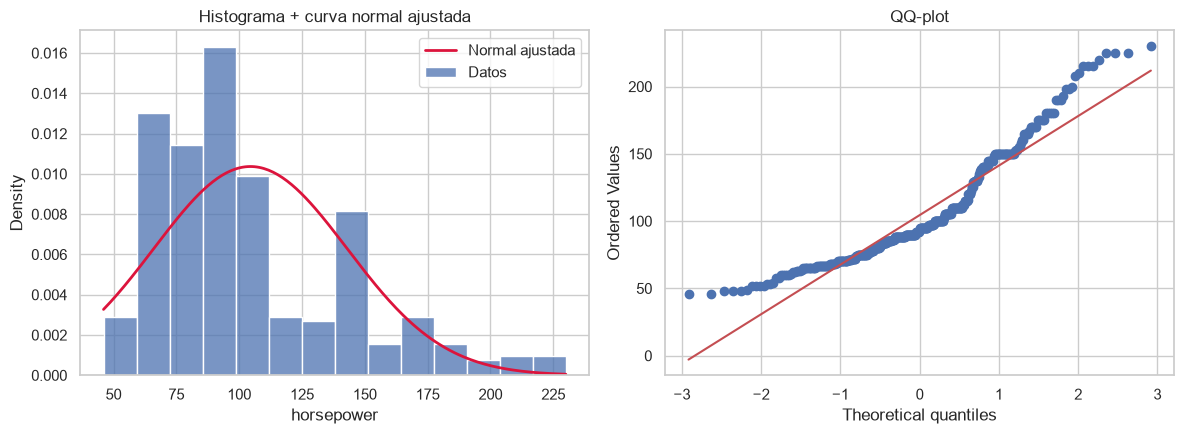

Asimetría: 1.08
Curtosis (exceso): 0.67
Shapiro-Wilk p-valor: 5.02e-15


In [35]:
mpg = sns.load_dataset("mpg")
horsepower = mpg["horsepower"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(horsepower, stat="density", ax=axes[0], color="#4C72B0", label="Datos")
x_hp = np.linspace(horsepower.min(), horsepower.max(), 200)
axes[0].plot(x_hp, stats.norm.pdf(x_hp, horsepower.mean(), horsepower.std()),
             color="crimson", linewidth=2, label="Normal ajustada")
axes[0].set_title("Histograma + curva normal ajustada")
axes[0].legend()

stats.probplot(horsepower, dist="norm", plot=axes[1])
axes[1].set_title("QQ-plot")

plt.tight_layout()
plt.show()

hp_skew = stats.skew(horsepower)
hp_kurtosis = stats.kurtosis(horsepower)
_, hp_p_value = stats.shapiro(horsepower)
print(f"Asimetría: {hp_skew:.2f}")
print(f"Curtosis (exceso): {hp_kurtosis:.2f}")
print(f"Shapiro-Wilk p-valor: {hp_p_value:.2e}")

El histograma se ve visiblemente desplazado hacia la izquierda con una cola larga a la derecha, la curva normal ajustada no calza bien, y en el QQ-plot los puntos se despegan de la diagonal en la cola derecha. La asimetría positiva y el p-valor de Shapiro-Wilk (muy por debajo de 0.05) confirman lo que ya sospechábamos desde la sesión 2: `horsepower` **no** sigue una distribución normal.

### Revisitando los valores atípicos: método IQR vs. método z-score

En la sesión anterior mencionamos que existe un método alternativo al IQR para detectar atípicos: marcar como atípico cualquier valor con $|z| > 3$. Ahora que sabemos evaluar normalidad, podemos ser más precisos: el método z-score asume que los datos son aproximadamente normales (para que "3 desviaciones estándar" sea un umbral razonable y poco frecuente); el método IQR no hace esa suposición, por eso es más seguro usarlo en variables como `horsepower`, que ya vimos que no son normales.

In [37]:
hp_mean, hp_std = horsepower.mean(), horsepower.std()
z_scores = (horsepower - hp_mean) / hp_std

zscore_outliers = (z_scores.abs() > 3).sum()
hp_q1, hp_q3 = horsepower.quantile([0.25, 0.75])
hp_iqr = hp_q3 - hp_q1
iqr_outliers = ((horsepower < hp_q1 - 1.5 * hp_iqr) | (horsepower > hp_q3 + 1.5 * hp_iqr)).sum()

print(f"Atípicos detectados con z-score (|z|>3): {zscore_outliers}")
print(f"Atípicos detectados con IQR: {iqr_outliers}")

Atípicos detectados con z-score (|z|>3): 5
Atípicos detectados con IQR: 10


### ¿Y si mis datos no son normales?

Dos caminos comunes:

1. **Transformar la variable.** Para datos positivos y sesgados a la derecha (como `horsepower`), una transformación logarítmica suele reducir la asimetría de forma notable.
2. **Usar un método que no asuma normalidad** (pruebas no paramétricas, que veremos más adelante en el curso).

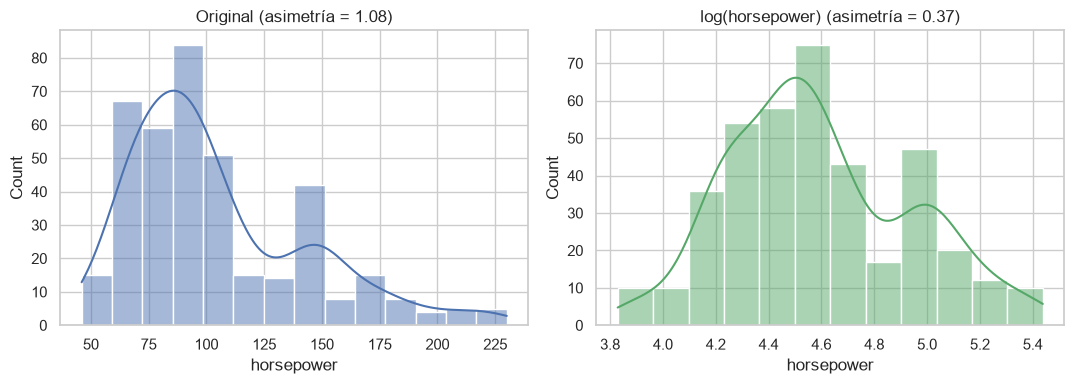

In [38]:
horsepower_log = np.log(horsepower)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(horsepower, kde=True, ax=axes[0])
axes[0].set_title(f"Original (asimetría = {stats.skew(horsepower):.2f})")
sns.histplot(horsepower_log, kde=True, ax=axes[1], color="#55A868")
axes[1].set_title(f"log(horsepower) (asimetría = {stats.skew(horsepower_log):.2f})")
plt.tight_layout()
plt.show()

**Ejercicio:** aplica a `mpg["weight"]` lo aprendido en esta sección: calcula su asimetría y curtosis, corre la prueba de Shapiro-Wilk e interpreta el p-valor, y grafica su histograma con curva normal ajustada junto a su QQ-plot.

In [21]:
# Ejercicio: evaluación de normalidad
# TODO 1: calcula asimetría y curtosis de mpg["weight"]
# TODO 2: aplica stats.shapiro e interpreta el p-valor (se rechaza / no se rechaza)
# TODO 3: grafica histograma + curva normal ajustada, y el QQ-plot

## Cierre

**Ideas clave de hoy:**

- Una distribución de probabilidad es un modelo teórico; discretas y continuas asignan probabilidades de forma distinta (sumas de PMF vs. áreas bajo una PDF).
- Cada distribución (binomial, Poisson, hipergeométrica, uniforme, normal, exponencial, y las demás mencionadas) corresponde a un tipo de proceso generador de datos distinto — elegir la distribución correcta depende del proceso, no solo de la forma de un histograma.
- El Teorema del Límite Central explica por qué la normal aparece tan seguido en estadística, incluso cuando los datos originales no lo son.
- Evaluar normalidad combina medidas numéricas (asimetría, curtosis), pruebas de hipótesis (interpretadas por su p-valor) y herramientas gráficas (histograma + curva ajustada, QQ-plot); ninguna por sí sola es suficiente.